In [1]:
using ForwardDiff, Plots, NLsolve, ProgressMeter

In [2]:
include("LobattoRKdata.jl")

LobattoRKdata (generic function with 1 method)

In [3]:
include("CoupledOscillatorTools.jl")

Coupled_Oscillator (generic function with 1 method)

In [4]:
omega = [0.5,0.5]; rho = 0.25;
KineticEnergy,PotentialEnergy = Coupled_Oscillator(omega);

In [5]:
include("DEL_tools.jl")

ComputeTrajectory (generic function with 1 method)

In [6]:
A,b,c = LobattoRKdata(1);  nodes = copy(c);

In [8]:
h = 0.2 ; 
DEL = DiscreteEL(KineticEnergy,PotentialEnergy,nodes,b,c,h);

In [9]:
q0_0 = [0.8,-0.5]
p0_0 = [0.4,0.0]
T_0 = 20 ; 
steps_0 = Int(T_0/h)
ts = 0:h:steps_0*h
ftol_0 = 1e-14

q = ComputeTrajectory(DEL,q0_0,p0_0,steps_0;ftol=1e-14)

p = ConjugateMomenta(DEL,q,steps=steps_0)


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


2×101 Matrix{Float64}:
 0.4          0.298927   0.196951   …  -0.0332723  -0.0397762  -0.0451867
 2.08167e-17  0.0485366  0.0937585      0.0273711   0.0283807   0.0287874

In [10]:
include("exact_solution.jl");

#ze = stack([q1.(ts),q2.(ts),p1.(ts),p2.(ts)],dims=1);

ze = vcat(q,p);

In [11]:
H(q,p) = 1/2*sum(q.^2) + 1/2* omega[1] * sum(q.^2);

H(z) = H(z[1:2],z[3:4]);

Hd=mapslices(H, ze,dims=1)

#writedlm("/home/hariz/Desktop/RKCQ_1206/errors/energy_exact.dat", [ts Hd'])
#writedlm("/home/hariz/Desktop/RKCQ_1206/errors/energy_Lobatto2s.dat", [ts Hd'])

1×101 Matrix{Float64}:
 0.6675  0.751853  0.808303  0.833421  …  0.00622801  0.00510706  0.0039818

In [21]:
plt1 = plot(q[1,:],p[1,:],xlabel="x1",ylabel="p1",label="");
plt2 = plot(ts,[q[1,:],q[2,:]],label=["x1" "x2"],xlabel="T",ylabel="x")

#plot(q1.(ts),p1.(ts),frame=:box,legend=false)

#plot(q[1,:])
#plot!(q[2,:])

plot(plt1,plt2,layout=(1,2),legend=:topright,grid=false,framestyle=:box)
savefig("exact_sol.pdf")

"/home/hariz/Desktop/RKCQ_1206/Coupled_Osci_2stage_Lobatto/exact_sol.pdf"

In [50]:
using  LinearAlgebra, DelimitedFiles

In [51]:

Ns=2 .^(5:12); T = 30; hs = T ./Ns; ftol_0 = 1e-14


m = length(Ns);

err_q = zeros(m);

err_p = zeros(m);

for i in 1:m

N = Ns[i]; h = T/N;   ts = (0:N)*h;

DEL = DiscreteEL(KineticEnergy,PotentialEnergy,nodes,b,c,h);    
    
q_Num = ComputeTrajectory(DEL,q0_0,p0_0,N,ftol=ftol_0);
p_Num = ConjugateMomenta(DEL,q_Num,steps=N)
   
q1_exact = q1.(ts);  
q2_exact = q2.(ts);  

p1_exact = p1.(ts);  
p2_exact = p2.(ts);  
    

    
 errq1 = abs.(q_Num[1,:] - q1_exact)
 errq2 = abs.(q_Num[2,:] - q2_exact)

err_q[i] = max(errq1..., errq2...)

errp1 = abs.(p_Num[1,:] - p1_exact)
errp2 = abs.(p_Num[2,:] - p2_exact)

err_p[i] = max(errp1..., errp2...)


    

end    

In [52]:
writedlm("/home/hariz/Desktop/RKCQ_1206/errors/q_err_2stage.dat", [hs err_q ])
writedlm("/home/hariz/Desktop/RKCQ_1206/errors/p_err_2stage.dat", [hs err_p])

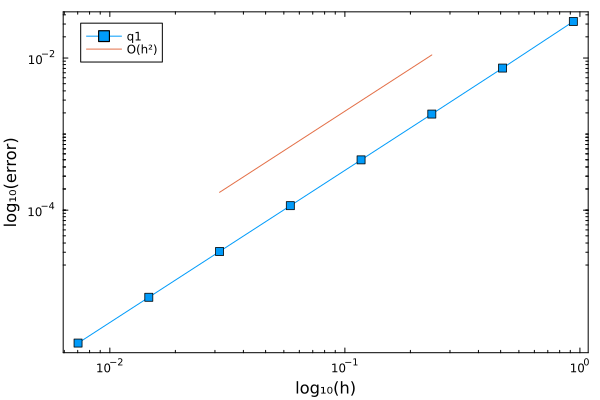

In [40]:
f(x)=0.2*x^2;

plt1=plot(xscale=:log10, yscale=:log10, legend=:topleft,xlabel="log₁₀(h)", ylabel="log₁₀(error)",minorticks=10,grid=false,framestyle=:box)

plot!(plt1,hs , err_p , m =:sq,label="q1")
#plot!(plt1,hs , err_q2 , m =:sq,label="q2")

plot!(plt1,hs[3:end-2] ,  f.(hs)[3:end-2],label="O(h²)")
